In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..")
from src.ingest import load_data

sns.set_theme(style="whitegrid")
%matplotlib inline

In [4]:
import os
os.chdir(r"C:\Users\prakh\tabular-ml-pipeline")

df = load_data("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape

Loaded 7032 rows, 20 columns
Churn rate: 26.58%
No nulls found


(7032, 20)

In [5]:
import os
print(os.getcwd())

C:\Users\prakh\tabular-ml-pipeline


In [6]:
os.chdir(r"C:\Users\prakh\tabular-ml-pipeline")
print(os.getcwd())


C:\Users\prakh\tabular-ml-pipeline


In [7]:
df = load_data("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape

Loaded 7032 rows, 20 columns
Churn rate: 26.58%
No nulls found


(7032, 20)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


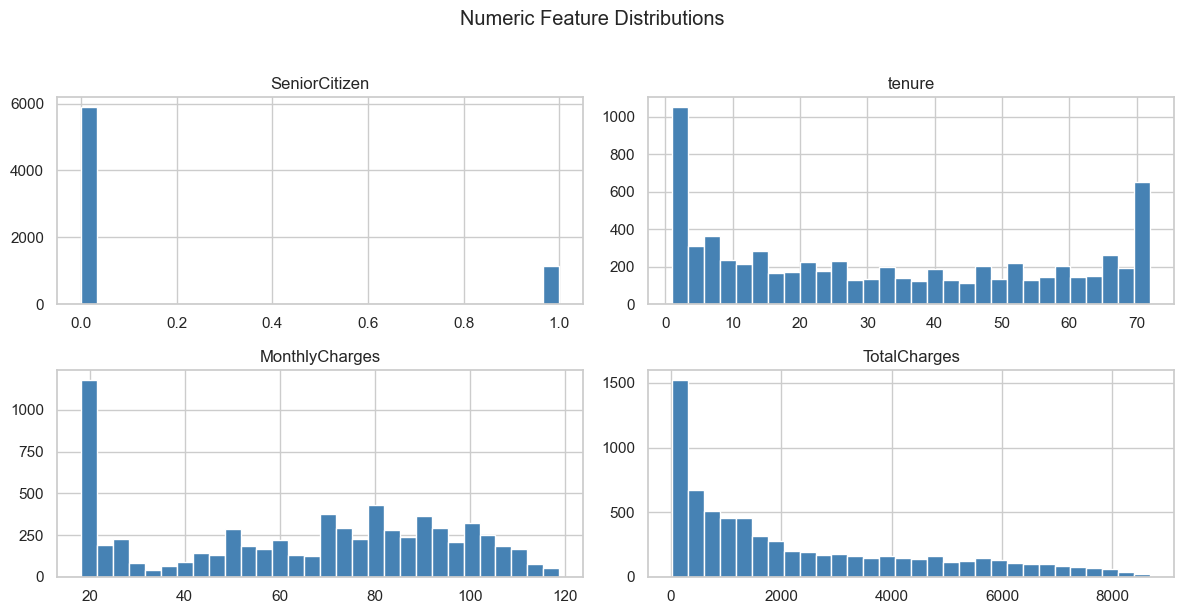

In [10]:
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
if "Churn" in num_cols:
    num_cols.remove("Churn")

print(num_cols)

df[num_cols].hist(bins=30, figsize=(12, 6), color="steelblue", edgecolor="white")
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig("reports/numeric_distributions.png")
plt.show()

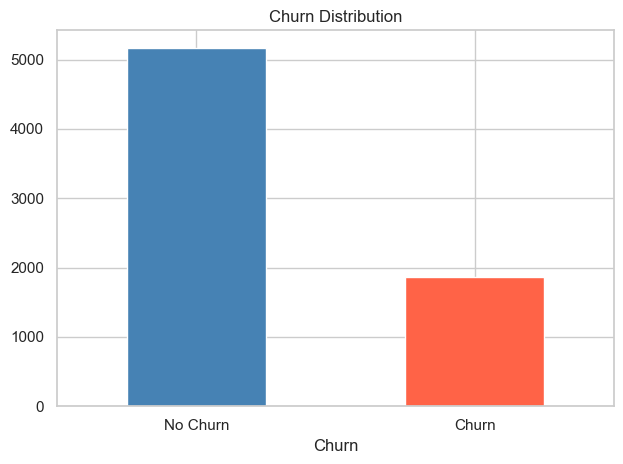

In [11]:
ax = df["Churn"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
ax.set_xticklabels(["No Churn", "Churn"], rotation=0)
ax.set_title("Churn Distribution")
plt.tight_layout()
plt.show()

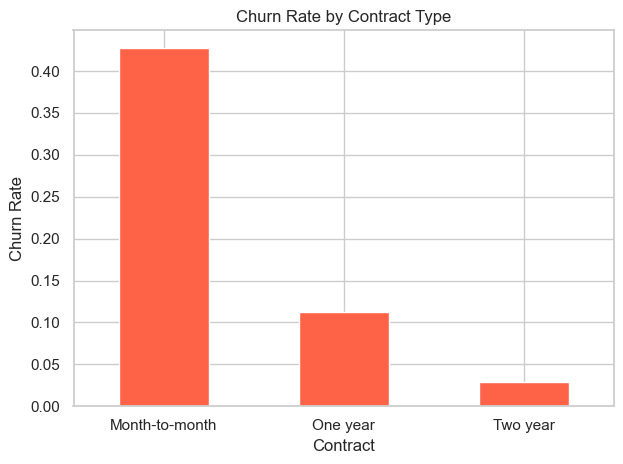

In [12]:
ct = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
ax = ct.plot(kind="bar", color="tomato")
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn Rate")
ax.set_xticklabels(ct.index, rotation=0)
plt.tight_layout()
plt.show()

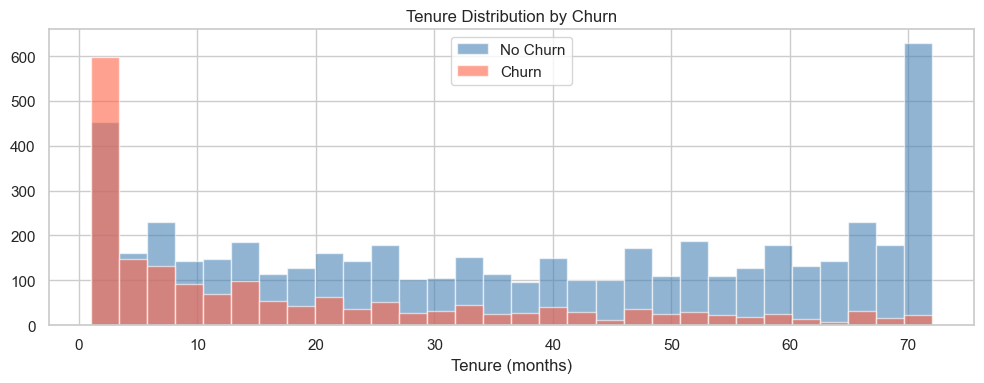

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
df[df["Churn"]==0]["tenure"].hist(bins=30, alpha=0.6, label="No Churn", color="steelblue", ax=ax)
df[df["Churn"]==1]["tenure"].hist(bins=30, alpha=0.6, label="Churn", color="tomato", ax=ax)
ax.set_title("Tenure Distribution by Churn")
ax.set_xlabel("Tenure (months)")
ax.legend()
plt.tight_layout()
plt.show()